# Task 1: Data Preparation

## Step 1: Import Libraries

In [4]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

print("TensorFlow version:", tf.__version__)
print("Keras version:", tf.keras.__version__)

TensorFlow version: 2.19.0
Keras version: 3.13.2


## Step 2: Define Data Loading Function

In [5]:
# Define dataset paths
train_dir = "/content/drive/MyDrive/Machine Learning/Week4/DevanagariHandwrittenDigitDataset/Train"
test_dir = "/content/drive/MyDrive/Machine Learning/Week4/DevanagariHandwrittenDigitDataset/Test"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    """
    Load images from folder structure and create feature matrix and labels.

    Parameters:
    - folder: Path to the folder containing class subdirectories

    Returns:
    - images: Numpy array of shape (n_samples, height, width)
    - labels: Numpy array of labels
    """
    images = []
    labels = []

    # Sorted class names (digit_0, digit_1, ..., digit_9)
    class_names = sorted(os.listdir(folder))

    # Map class names to labels - EXTRACT DIGIT FROM FOLDER NAME
    class_map = {name: int(name.split('_')[1]) for name in class_names}

    print(f"Loading data from: {folder}")
    print(f"Classes found: {class_names}")
    print(f"Class mapping: {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)

        # Skip if not a directory
        if not os.path.isdir(class_path):
            continue

        label = class_map[class_name]

        # Count images in this class
        image_count = 0

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            try:
                # Load image using PIL
                img = Image.open(img_path).convert("L")  # Convert to grayscale
                img = img.resize((img_width, img_height))  # Resize to (28,28)
                img = np.array(img) / 255.0  # Normalize pixel values to [0,1]

                images.append(img)
                labels.append(label)  # THIS IS THE FIX - use extracted label
                image_count += 1
            except Exception as e:
                print(f"Error loading {img_path}: {e}")

        print(f"  {class_name} (label={label}): {image_count} images loaded")

    return np.array(images), np.array(labels)

## Step 3: Load Training and Testing Data

In [6]:
# Load training and testing datasets
x_train, y_train = load_images_from_folder(train_dir)
x_test, y_test = load_images_from_folder(test_dir)

print("\n" + "-"*60)
print("Dataset loaded successfully!")
print("-"*60)
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# CRITICAL: Shuffle the training data
print("\n" + "+"*60)
print("SHUFFLING TRAINING DATA")
print("+"*60)

print("\nBefore shuffle - First 20 labels:", y_train[:20])

# Create random permutation indices
np.random.seed(42)  # For reproducibility
shuffle_indices = np.random.permutation(len(x_train))

# Shuffle both features and labels using the same indices
x_train = x_train[shuffle_indices]
y_train = y_train[shuffle_indices]

print("After shuffle - First 20 labels:", y_train[:20])
print("\n✓ Training data shuffled successfully!")

Loading data from: /content/drive/MyDrive/Machine Learning/Week4/DevanagariHandwrittenDigitDataset/Train
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
Class mapping: {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}
  digit_0 (label=0): 1700 images loaded
  digit_1 (label=1): 1700 images loaded
  digit_2 (label=2): 1700 images loaded
  digit_3 (label=3): 1700 images loaded
  digit_4 (label=4): 1700 images loaded
  digit_5 (label=5): 1700 images loaded
  digit_6 (label=6): 1700 images loaded
  digit_7 (label=7): 1700 images loaded
  digit_8 (label=8): 1700 images loaded
  digit_9 (label=9): 1700 images loaded
Loading data from: /content/drive/MyDrive/Machine Learning/Week4/DevanagariHandwrittenDigitDataset/Test
Classes found: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digi

## Verification

In [7]:
# Verify shuffling worked
print("POST-SHUFFLE VERIFICATION")
print("="*60)

# Check first 50 labels (should see variety now)
print(f"\nFirst 50 training labels:")
print(y_train[:50])

# Count unique in first 50
unique_in_first_50 = len(np.unique(y_train[:50]))
print(f"\nUnique labels in first 50 samples: {unique_in_first_50}")

if unique_in_first_50 >= 8:  # Should see most digits in first 50
    print(" Data is properly shuffled!")
elif unique_in_first_50 >= 5:
    print(" Data has some variety")
else:
    print("POOR: Data still not shuffled properly")

# Verify distribution is still correct
print("\nVerifying class distribution after shuffle:")
for i in range(10):
    count = np.sum(y_train == i)
    print(f"  Digit {i}: {count} samples")


POST-SHUFFLE VERIFICATION

First 50 training labels:
[6 3 6 1 3 2 4 2 9 5 0 6 8 7 5 8 5 0 6 7 8 3 6 9 7 2 8 5 0 9 0 1 6 3 4 4 1
 2 3 6 4 9 3 4 5 4 2 4 9 6]

Unique labels in first 50 samples: 10
 Data is properly shuffled!

Verifying class distribution after shuffle:
  Digit 0: 1700 samples
  Digit 1: 1700 samples
  Digit 2: 1700 samples
  Digit 3: 1700 samples
  Digit 4: 1700 samples
  Digit 5: 1700 samples
  Digit 6: 1700 samples
  Digit 7: 1700 samples
  Digit 8: 1700 samples
  Digit 9: 1700 samples


## Step 4: Reshape Images for Keras

In [8]:
# Reshape images for Keras input
# For fully connected network, we need to flatten the images
x_train_flat = x_train.reshape(-1, img_height * img_width)  # Shape (num_samples, 784)
x_test_flat = x_test.reshape(-1, img_height * img_width)

print(f"Flattened training set: {x_train_flat.shape}")
print(f"Flattened testing set: {x_test_flat.shape}")

Flattened training set: (17000, 784)
Flattened testing set: (3000, 784)


## Step 5: One-Hot Encode Labels

In [9]:
# One-hot encode labels
num_classes = 10
y_train_encoded = to_categorical(y_train, num_classes=num_classes)
y_test_encoded = to_categorical(y_test, num_classes=num_classes)

print(f"One-hot encoded training labels: {y_train_encoded.shape}")
print(f"One-hot encoded testing labels: {y_test_encoded.shape}")
print(f"\nExample - Original label: {y_train[0]}")
print(f"One-hot encoded: {y_train_encoded[0]}")

One-hot encoded training labels: (17000, 10)
One-hot encoded testing labels: (3000, 10)

Example - Original label: 6
One-hot encoded: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [10]:
# Data Distribution Analysis
print("DATA DISTRIBUTION ANALYSIS")
print("-"*60)

# Check label distribution
print("\n1. Label Distribution:")
print(f"   Training labels range: {y_train.min()} to {y_train.max()}")
print(f"   Test labels range: {y_test.min()} to {y_test.max()}")

print("\n2. Training Set Distribution:")
train_unique, train_counts = np.unique(y_train, return_counts=True)
for label, count in zip(train_unique, train_counts):
    print(f"   Class {label}: {count} samples ({count/len(y_train)*100:.1f}%)")

print("\n3. Test Set Distribution:")
test_unique, test_counts = np.unique(y_test, return_counts=True)
for label, count in zip(test_unique, test_counts):
    print(f"   Class {label}: {count} samples ({count/len(y_test)*100:.1f}%)")

# Check pixel value ranges
print("\n4. Pixel Value Ranges:")
print(f"   Training data: min={x_train_flat.min():.4f}, max={x_train_flat.max():.4f}, mean={x_train_flat.mean():.4f}")
print(f"   Test data: min={x_test_flat.min():.4f}, max={x_test_flat.max():.4f}, mean={x_test_flat.mean():.4f}")

# Check for data contamination
print("\n5. Sample Verification:")
print(f"   First 10 training labels: {y_train[:10]}")
print(f"   First 10 test labels: {y_test[:10]}")


DATA DISTRIBUTION ANALYSIS
------------------------------------------------------------

1. Label Distribution:
   Training labels range: 0 to 9
   Test labels range: 0 to 9

2. Training Set Distribution:
   Class 0: 1700 samples (10.0%)
   Class 1: 1700 samples (10.0%)
   Class 2: 1700 samples (10.0%)
   Class 3: 1700 samples (10.0%)
   Class 4: 1700 samples (10.0%)
   Class 5: 1700 samples (10.0%)
   Class 6: 1700 samples (10.0%)
   Class 7: 1700 samples (10.0%)
   Class 8: 1700 samples (10.0%)
   Class 9: 1700 samples (10.0%)

3. Test Set Distribution:
   Class 0: 300 samples (10.0%)
   Class 1: 300 samples (10.0%)
   Class 2: 300 samples (10.0%)
   Class 3: 300 samples (10.0%)
   Class 4: 300 samples (10.0%)
   Class 5: 300 samples (10.0%)
   Class 6: 300 samples (10.0%)
   Class 7: 300 samples (10.0%)
   Class 8: 300 samples (10.0%)
   Class 9: 300 samples (10.0%)

4. Pixel Value Ranges:
   Training data: min=0.0000, max=1.0000, mean=0.2420
   Test data: min=0.0000, max=1.0000, me

In [11]:
# CRITICAL VERIFICATION
print("LABEL VERIFICATION")
print("="*60)

print("\n✓ Checking if labels are correctly distributed...")

# Check first 50 labels (should see variety)
print(f"\nFirst 50 training labels:")
print(y_train[:50])

print(f"\nUnique labels in training set: {sorted(np.unique(y_train))}")
print(f"Unique labels in test set: {sorted(np.unique(y_test))}")

# Count per class
print("\nTraining set - samples per class:")
for i in range(10):
    count = np.sum(y_train == i)
    print(f"  Digit {i}: {count} samples")

print("\nTest set - samples per class:")
for i in range(10):
    count = np.sum(y_test == i)
    print(f"  Digit {i}: {count} samples")

# CRITICAL CHECK
if len(np.unique(y_train)) == 10 and len(np.unique(y_test)) == 10:
    print("\n All 10 digit classes present!")
else:
    print("\n Missing digit classes!")

# Check if first 50 labels have variety
unique_in_first_50 = len(np.unique(y_train[:50]))
if unique_in_first_50 > 1:
    print(f"PASS: Found {unique_in_first_50} different labels in first 50 samples")
else:
    print(f"FAIL: Only {unique_in_first_50} label in first 50 samples - data not properly loaded!")


LABEL VERIFICATION

✓ Checking if labels are correctly distributed...

First 50 training labels:
[6 3 6 1 3 2 4 2 9 5 0 6 8 7 5 8 5 0 6 7 8 3 6 9 7 2 8 5 0 9 0 1 6 3 4 4 1
 2 3 6 4 9 3 4 5 4 2 4 9 6]

Unique labels in training set: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Unique labels in test set: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Training set - samples per class:
  Digit 0: 1700 samples
  Digit 1: 1700 samples
  Digit 2: 1700 samples
  Digit 3: 1700 samples
  Digit 4: 1700 samples
  Digit 5: 1700 samples
  Digit 6: 1700 samples
  Digit 7: 1700 samples
  Digit 8: 1700 samples
  Digit 9: 1700 samples

Test set - samples per class:
  Digit 0: 300 samples
  Digit 1: 300 samples
  Digit 2: 300 samples
  Digit 3: 300 samples
  Digit 4: 300 samples
  Digit 5: 300 samples
  Digit 6: 300 samples
  Digit 7: 3

## Step 6: Visualize Sample Images

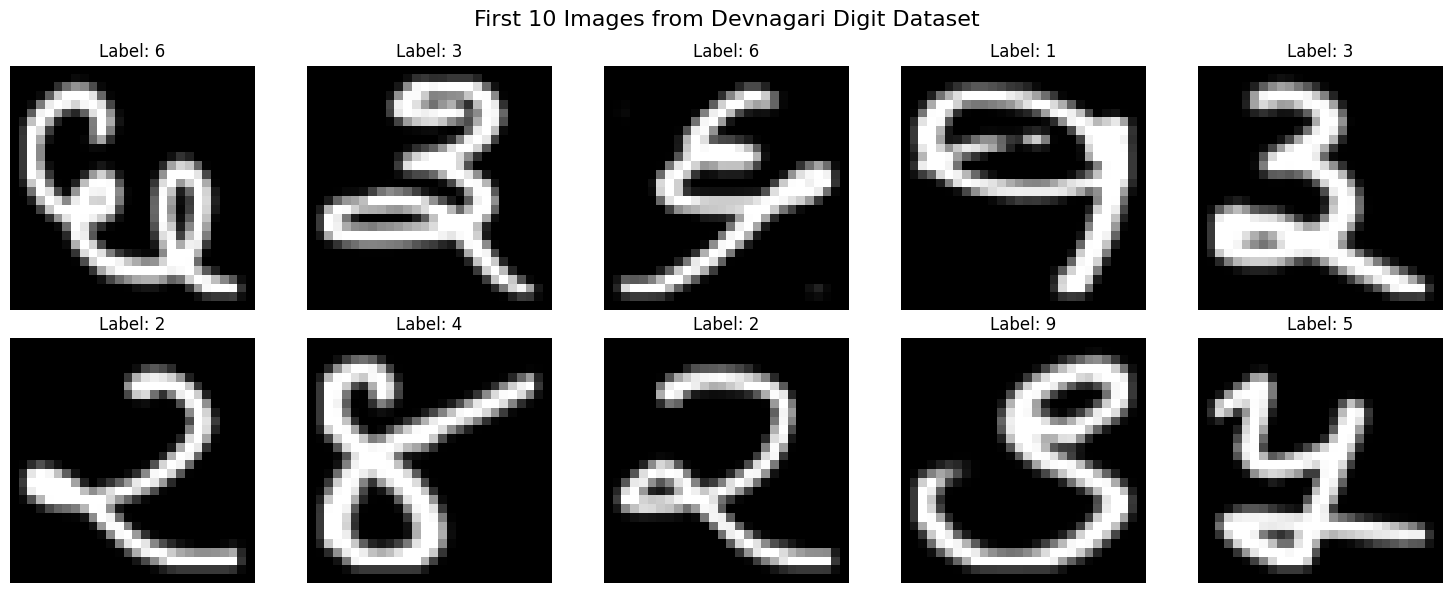

In [12]:
# Visualize some images from the training set
plt.figure(figsize=(15, 6))

# Display 10 random images from each class
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.suptitle("First 10 Images from Devnagari Digit Dataset", fontsize=16)
plt.tight_layout()
plt.show()

## Step 7: Visualize Class Distribution

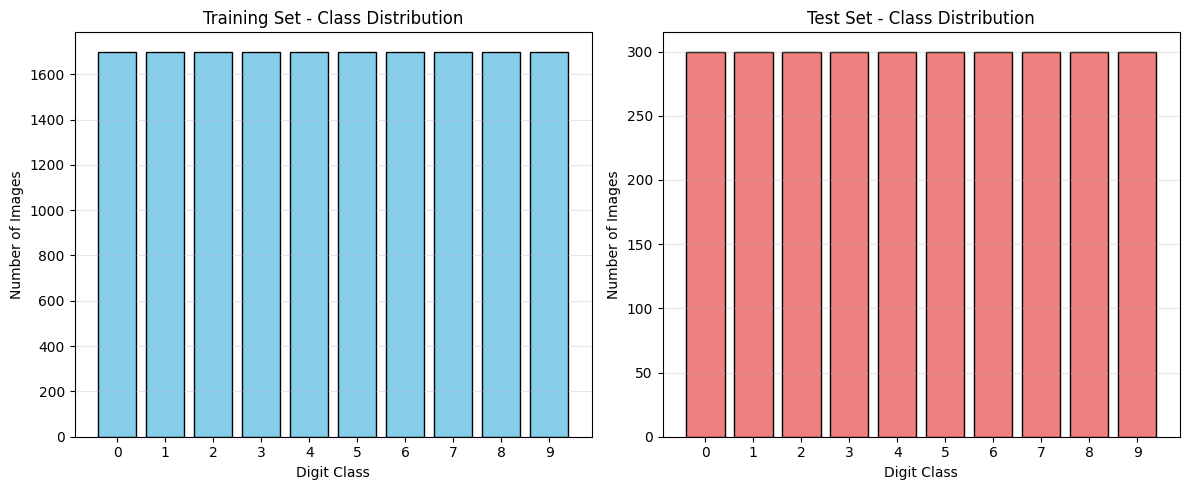

In [13]:
# Visualize class distribution
unique, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(unique, counts, color='skyblue', edgecolor='black')
plt.xlabel('Digit Class')
plt.ylabel('Number of Images')
plt.title('Training Set - Class Distribution')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)

unique_test, counts_test = np.unique(y_test, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_test, counts_test, color='lightcoral', edgecolor='black')
plt.xlabel('Digit Class')
plt.ylabel('Number of Images')
plt.title('Test Set - Class Distribution')
plt.xticks(unique_test)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Task 2: Build the FCN Model

## Step 8: Build Model Using Sequential API

In [14]:
from tensorflow import keras
from tensorflow.keras import layers

# Clear any existing models
tf.keras.backend.clear_session()

# Model parameters
num_classes = 10
input_shape = (img_height * img_width,)  # 784 for flattened 28x28 images

# Build the model
model = keras.Sequential([
    keras.layers.Input(shape=input_shape),

    # Hidden layers with ReLU activation and Dropout
    keras.layers.Dense(64, activation="relu", name="hidden_layer_1"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation="relu", name="hidden_layer_2"),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(256, activation="relu", name="hidden_layer_3"),
    keras.layers.Dropout(0.3),

    # Output layer with softmax activation
    keras.layers.Dense(num_classes, activation="softmax", name="output_layer"),
])

print("Model built successfully!")

Model built successfully!


## Step 9: Display Model Summary

In [15]:
# Display model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

# Task 3: Compile the Model

## Step 10: Compile the Model

In [16]:
from tensorflow.keras.optimizers import Adam

# Compile the model with specific learning rate
optimizer = Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print("\nOptimizer: Adam (learning_rate=0.001)")
print("Loss Function: Categorical Crossentropy")
print("Metrics: Accuracy")

Model compiled successfully!

Optimizer: Adam (learning_rate=0.001)
Loss Function: Categorical Crossentropy
Metrics: Accuracy


# Task 4: Train the Model

## Step 11: Define Training Parameters and Callbacks

In [17]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Training parameters
batch_size = 128
epochs = 50

# Callbacks
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=10,
        verbose=1,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="best_devnagari_model.h5",
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Training Configuration:")
print(f"  Batch Size: {batch_size}")
print(f"  Max Epochs: {epochs}")
print(f"  Validation Split: 20%")
print(f"  Callbacks:")
print(f"    - EarlyStopping (patience=10)")
print(f"    - ReduceLROnPlateau (patience=5)")
print(f"    - ModelCheckpoint (save_best_only=True)")

Training Configuration:
  Batch Size: 128
  Max Epochs: 50
  Validation Split: 20%
  Callbacks:
    - EarlyStopping (patience=10)
    - ReduceLROnPlateau (patience=5)
    - ModelCheckpoint (save_best_only=True)


## Step 12: Train the Model

In [18]:
# Train the model
print("\n" + "="*60)
print("Starting Model Training...")
print("="*60 + "\n")

history = model.fit(
    x_train_flat,
    y_train_encoded,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,  # 20% of training data for validation
    callbacks=callbacks,
    verbose=1
)

print("\n" + "="*60)
print("Training Completed!")
print("="*60)


Starting Model Training...

Epoch 1/50
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4894 - loss: 1.4550
Epoch 1: val_accuracy improved from None to 0.90559, saving model to best_devnagari_model.h5



Epoch 1: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.6768 - loss: 0.9354 - val_accuracy: 0.9056 - val_loss: 0.2860 - learning_rate: 0.0010
Epoch 2/50
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8802 - loss: 0.3639
Epoch 2: val_accuracy improved from 0.90559 to 0.94441, saving model to best_devnagari_model.h5



Epoch 2: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8891 - loss: 0.3382 - val_accuracy: 0.9444 - val_loss: 0.1745 - learning_rate: 0.0010
Epoch 3/50
 94/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9161 - loss: 0.2602
Epoch 3: val_accuracy improved from 0.94441 to 0.95235, saving model to best_devnagari_model.h5



Epoch 3: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9191 - loss: 0.2450 - val_accuracy: 0.9524 - val_loss: 0.1397 - learning_rate: 0.0010
Epoch 4/50
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9275 - loss: 0.2146
Epoch 4: val_accuracy improved from 0.95235 to 0.95794, saving model to best_devnagari_model.h5



Epoch 4: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9301 - loss: 0.2054 - val_accuracy: 0.9579 - val_loss: 0.1240 - learning_rate: 0.0010
Epoch 5/50
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9415 - loss: 0.1771
Epoch 5: val_accuracy improved from 0.95794 to 0.96265, saving model to best_devnagari_model.h5


...


Epoch 12: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9682 - loss: 0.1001 - val_accuracy: 0.9753 - val_loss: 0.0850 - learning_rate: 0.0010
Epoch 13/50
104/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9664 - loss: 0.1030
Epoch 13: val_accuracy did not improve from 0.97529
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9674 - loss: 0.1041 - val_accuracy: 0.9744 - val_loss: 0.0873 - learning_rate: 0.0010
Epoch 14/50
 94/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9687 - loss: 0.0954
Epoch 14: val_accuracy improved from 0.97529 to 0.97559, saving model to best_devnagari_model.h5



Epoch 14: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9721 - loss: 0.0880 - val_accuracy: 0.9756 - val_loss: 0.0837 - learning_rate: 0.0010
Epoch 15/50
106/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9716 - loss: 0.0842
Epoch 15: val_accuracy improved from 0.97559 to 0.97794, saving model to best_devnagari_model.h5



Epoch 15: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9700 - loss: 0.0886 - val_accuracy: 0.9779 - val_loss: 0.0751 - learning_rate: 0.0010
Epoch 16/50
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9762 - loss: 0.0770
Epoch 16: val_accuracy did not improve from 0.97794
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9738 - loss: 0.0847 - val_accuracy: 0.9771 - val_loss: 0.0778 - learning_rate: 0.0010
Epoch 17/50
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9780 - loss: 0.0729
Epoch 17: val_accuracy improved from 0.97794 to 0.97912, saving model to best_devnagari_model.h5



Epoch 17: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9763 - loss: 0.0749 - val_accuracy: 0.9791 - val_loss: 0.0741 - learning_rate: 0.0010
Epoch 18/50
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9756 - loss: 0.0754
Epoch 18: val_accuracy did not improve from 0.97912
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9735 - loss: 0.0777 - val_accuracy: 0.9785 - val_loss: 0.0813 - learning_rate: 0.0010
Epoch 19/50
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9749 - loss: 0.0727
Epoch 19: val_accuracy did not improve from 0.97912
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9755 - loss: 0.0716 - val_accuracy: 0.9738 - val_loss: 0.0915 - learning_rate: 0.0010
Epoch 20/50
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9713 - loss: 0.0868
Epoch 20: val_accuracy did not improve from 0.97912
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9740 - loss: 0.0815 - val_accuracy: 0.9765 - 


Epoch 24: finished saving model to best_devnagari_model.h5
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9825 - loss: 0.0549 - val_accuracy: 0.9806 - val_loss: 0.0787 - learning_rate: 5.0000e-04
Epoch 25/50
 91/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9819 - loss: 0.0554
Epoch 25: val_accuracy did not improve from 0.98059
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9826 - loss: 0.0549 - val_accuracy: 0.9791 - val_loss: 0.0758 - learning_rate: 5.0000e-04
Epoch 26/50
 97/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9839 - loss: 0.0518
Epoch 26: val_accuracy did not improve from 0.98059
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9840 - loss: 0.0538 - val_accuracy: 0.9791 - val_loss: 0.0815 - learning_rate: 5.0000e-04
Epoch 27/50
100/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9859 - loss: 0.0432
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 27: val_accuracy did not improve from 0.98059
107/107 ━━

## Overfitting Check

In [19]:
# Overfitting Analysis
print("OVERFITTING CHECK")
print("-"*60)

final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

gap_acc = final_train_acc - final_val_acc
gap_loss = final_val_loss - final_train_loss

print(f"\nFinal Epoch Results:")
print(f"  Training Accuracy: {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"  Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"  Accuracy Gap: {gap_acc:.4f}")
print(f"\n  Training Loss: {final_train_loss:.4f}")
print(f"  Validation Loss: {final_val_loss:.4f}")
print(f"  Loss Gap: {gap_loss:.4f}")

print("\nDiagnosis:")
if gap_acc < 0.05 and gap_loss < 0.5:
    print("  No overfitting - model generalizes well!")
elif gap_acc < 0.10 and gap_loss < 1.0:
    print("  Minor overfitting - acceptable performance")
elif gap_acc < 0.15 and gap_loss < 2.0:
    print("  Moderate overfitting - consider more regularization")
else:
    print("  Severe overfitting - major problem detected!")

if final_val_acc < 0.10:
    print("  CRITICAL: Validation accuracy extremely low - check your data!")
elif final_val_acc < 0.70:
    print("  WARNING: Validation accuracy is low - model needs improvement")
elif final_val_acc < 0.85:
    print("  ACCEPTABLE: Validation accuracy is reasonable")
else:
    print("  EXCELLENT: High validation accuracy achieved")

print("="*60)

OVERFITTING CHECK
------------------------------------------------------------

Final Epoch Results:
  Training Accuracy: 0.9843 (98.43%)
  Validation Accuracy: 0.9791 (97.91%)
  Accuracy Gap: 0.0052

  Training Loss: 0.0502
  Validation Loss: 0.0757
  Loss Gap: 0.0255

Diagnosis:
  No overfitting - model generalizes well!
  EXCELLENT: High validation accuracy achieved


# Task 5: Evaluate the Model

## Step 13: Evaluate on Test Set

In [20]:
# Evaluate the model on test set
print("\n" + "="*60)
print("Evaluating Model on Test Set...")
print("="*60 + "\n")

test_loss, test_acc = model.evaluate(x_test_flat, y_test_encoded, verbose=2)

print("\n" + "="*60)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print("="*60)


Evaluating Model on Test Set...

94/94 - 1s - 12ms/step - accuracy: 0.9773 - loss: 0.0768

Test Loss: 0.0768
Test Accuracy: 0.9773 (97.73%)


# Task 6: Save and Load the Model

## Step 14: Save the Model

In [21]:
import os

# Save the trained model
model_filename = 'devnagari_fcn_model.h5'

try:
    model.save(model_filename)
    print(f"Model saved successfully as: {model_filename}")

    # Check file size
    file_size = os.path.getsize(model_filename) / (1024 * 1024)
    print(f"  File size: {file_size:.2f} MB")
    print(f"  File location: {os.path.abspath(model_filename)}")

except Exception as e:
    print(f"Error saving model: {e}")

Model saved successfully as: devnagari_fcn_model.h5
  File size: 1.12 MB
  File location: /content/devnagari_fcn_model.h5


## Step 15: Load the Model

In [22]:
# Load the saved model
loaded_model = tf.keras.models.load_model(model_filename)

print(f"Model loaded successfully from: {model_filename}")
print("\nModel Summary:")
loaded_model.summary()

Model loaded successfully from: devnagari_fcn_model.h5

Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

## Step 16: Re-evaluate Loaded Model

In [23]:
# Re-evaluate the loaded model
print("Re-evaluating Loaded Model on Test Set...")
print("="*60 + "\n")

loaded_test_loss, loaded_test_acc = loaded_model.evaluate(
    x_test_flat,
    y_test_encoded,
    verbose=2
)

print("\n" + "-"*60)
print(f"Loaded Model - Test Loss: {loaded_test_loss:.4f}")
print(f"Loaded Model - Test Accuracy: {loaded_test_acc:.4f} ({loaded_test_acc*100:.2f}%)")

Re-evaluating Loaded Model on Test Set...

94/94 - 1s - 13ms/step - accuracy: 0.9773 - loss: 0.0768

------------------------------------------------------------
Loaded Model - Test Loss: 0.0768
Loaded Model - Test Accuracy: 0.9773 (97.73%)


# Task 7: Make Predictions

## Step 17: Predict on Test Images

In [24]:
# Make predictions on test data
predictions = model.predict(x_test_flat)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test_encoded, axis=1)

print("Predictions completed!")
print(f"\nFirst 10 predictions:")
print(f"Predicted: {predicted_labels[:10]}")
print(f"True:      {true_labels[:10]}")

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Predictions completed!

First 10 predictions:
Predicted: [0 0 0 0 0 0 0 0 0 0]
True:      [0 0 0 0 0 0 0 0 0 0]


## Step 18: Visualize Predictions

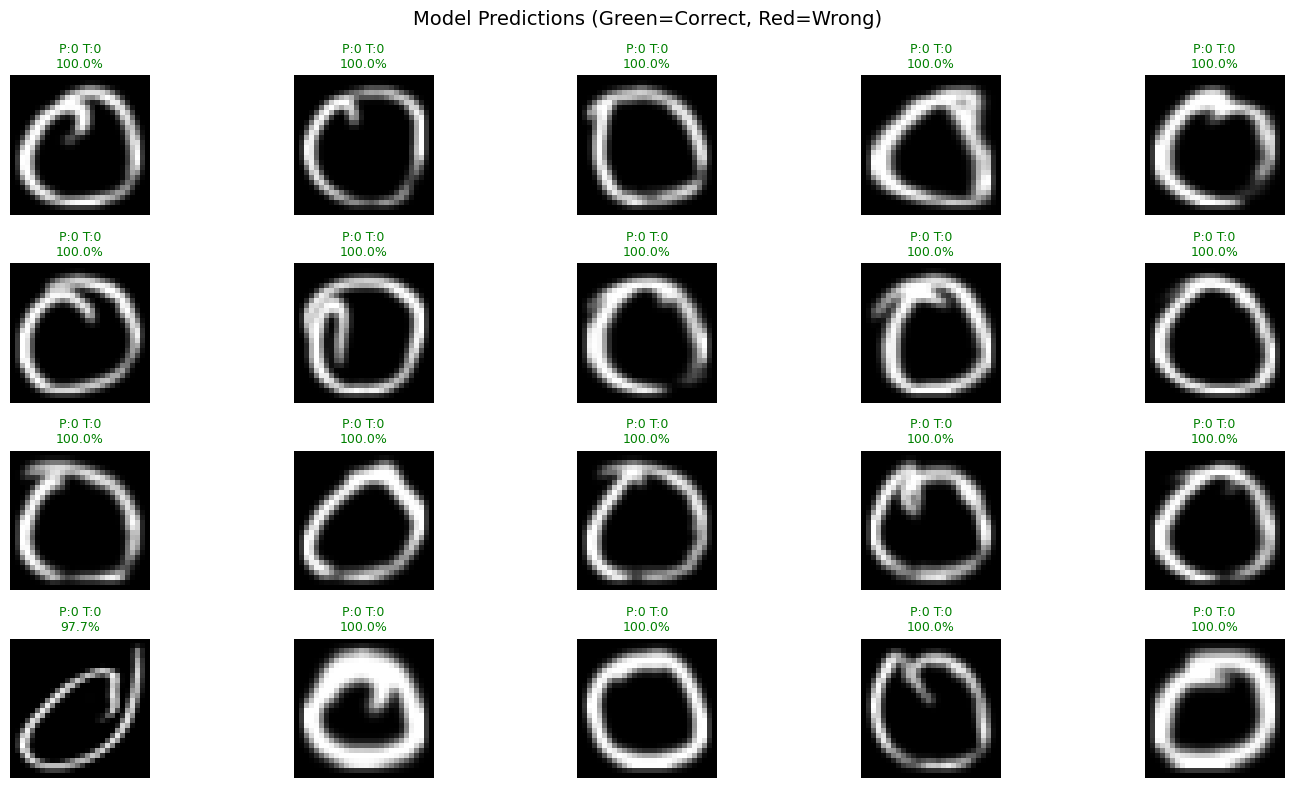

In [25]:
# Visualize predictions with confidence scores
plt.figure(figsize=(15, 8))

num_images = 20
for i in range(num_images):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    predicted = predicted_labels[i]
    true = true_labels[i]
    confidence = predictions[i][predicted] * 100

    # Color: green if correct, red if wrong
    color = 'green' if predicted == true else 'red'

    plt.title(f"P:{predicted} T:{true}\n{confidence:.1f}%",
              fontsize=9, color=color)
    plt.axis("off")

plt.suptitle("Model Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout()
plt.show()

## Step 19: Display Prediction Statistics

In [26]:
# Calculate and display prediction statistics
correct_predictions = np.sum(predicted_labels == true_labels)
total_predictions = len(true_labels)
accuracy = (correct_predictions / total_predictions) * 100

print("Prediction Statistics")
print("-"*60)
print(f"Total Test Samples: {total_predictions}")
print(f"Correct Predictions: {correct_predictions}")
print(f"Incorrect Predictions: {total_predictions - correct_predictions}")
print(f"Accuracy: {accuracy:.2f}%")

Prediction Statistics
------------------------------------------------------------
Total Test Samples: 3000
Correct Predictions: 2932
Incorrect Predictions: 68
Accuracy: 97.73%


#Visualization

## Visualize Training History (Loss)

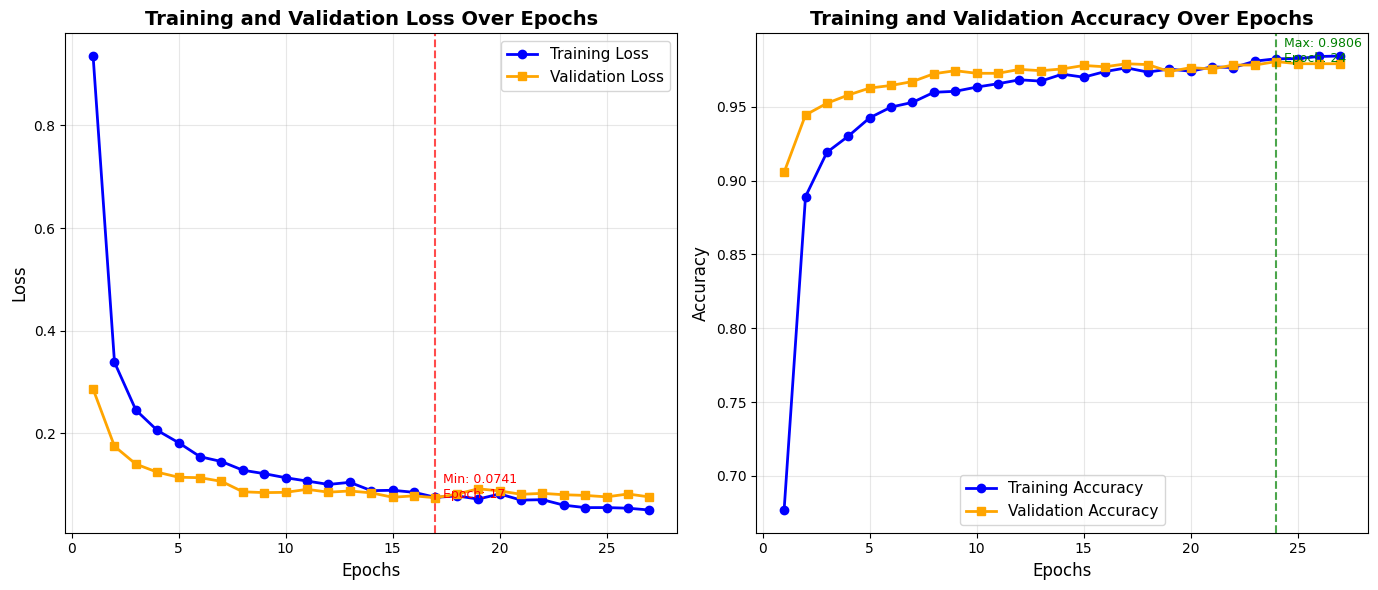

In [27]:
# Extract training history
train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Plot training and validation loss
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss,
         label='Training Loss', color='blue', linewidth=2, marker='o')
plt.plot(range(1, len(val_loss) + 1), val_loss,
         label='Validation Loss', color='orange', linewidth=2, marker='s')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Highlight minimum validation loss
min_val_loss_epoch = np.argmin(val_loss) + 1
min_val_loss = np.min(val_loss)
plt.axvline(x=min_val_loss_epoch, color='red', linestyle='--', alpha=0.7)
plt.text(min_val_loss_epoch, min_val_loss,
         f'  Min: {min_val_loss:.4f}\n  Epoch: {min_val_loss_epoch}',
         fontsize=9, color='red')

plt.subplot(1, 2, 2)
# Plot accuracy
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(range(1, len(train_acc) + 1), train_acc,
         label='Training Accuracy', color='blue', linewidth=2, marker='o')
plt.plot(range(1, len(val_acc) + 1), val_acc,
         label='Validation Accuracy', color='orange', linewidth=2, marker='s')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

# Highlight maximum validation accuracy
max_val_acc_epoch = np.argmax(val_acc) + 1
max_val_acc = np.max(val_acc)
plt.axvline(x=max_val_acc_epoch, color='green', linestyle='--', alpha=0.7)
plt.text(max_val_acc_epoch, max_val_acc,
         f'  Max: {max_val_acc:.4f}\n  Epoch: {max_val_acc_epoch}',
         fontsize=9, color='green')

plt.tight_layout()
plt.show()

## Confusion Matrix

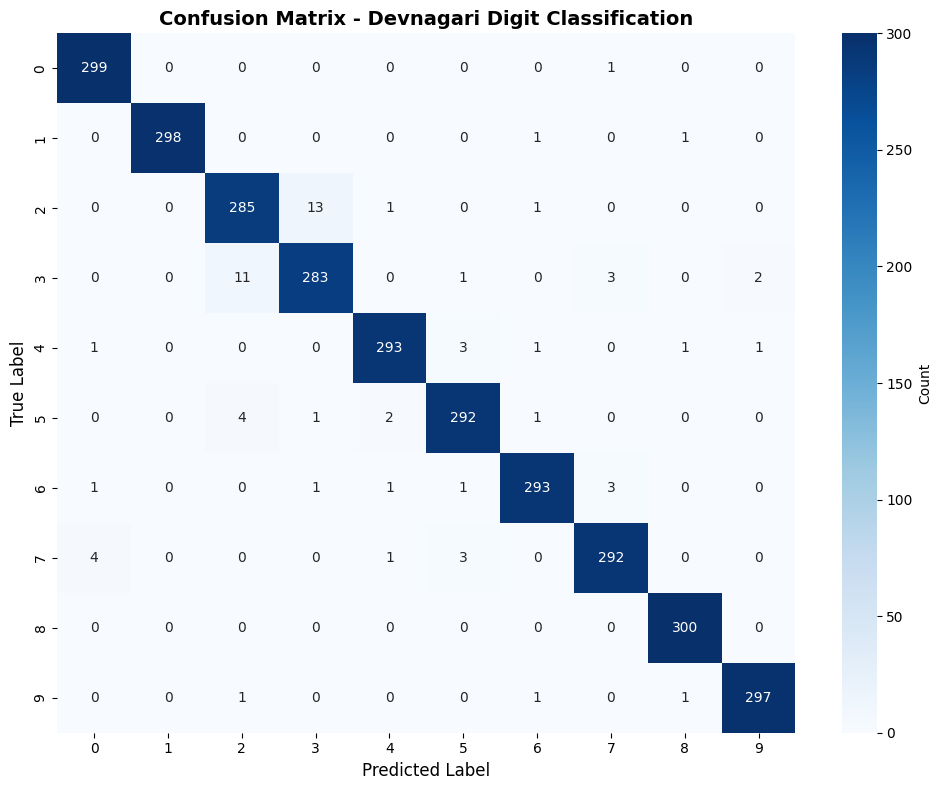

In [28]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Calculate confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Devnagari Digit Classification',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Classification Report

In [29]:
# Print detailed classification report
print("Classification Report")
print("+"*60)
print(classification_report(true_labels, predicted_labels,
                          target_names=[f"Digit {i}" for i in range(10)]))

Classification Report
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
              precision    recall  f1-score   support

     Digit 0       0.98      1.00      0.99       300
     Digit 1       1.00      0.99      1.00       300
     Digit 2       0.95      0.95      0.95       300
     Digit 3       0.95      0.94      0.95       300
     Digit 4       0.98      0.98      0.98       300
     Digit 5       0.97      0.97      0.97       300
     Digit 6       0.98      0.98      0.98       300
     Digit 7       0.98      0.97      0.97       300
     Digit 8       0.99      1.00      1.00       300
     Digit 9       0.99      0.99      0.99       300

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000



## Per-Class Accuracy Visualization

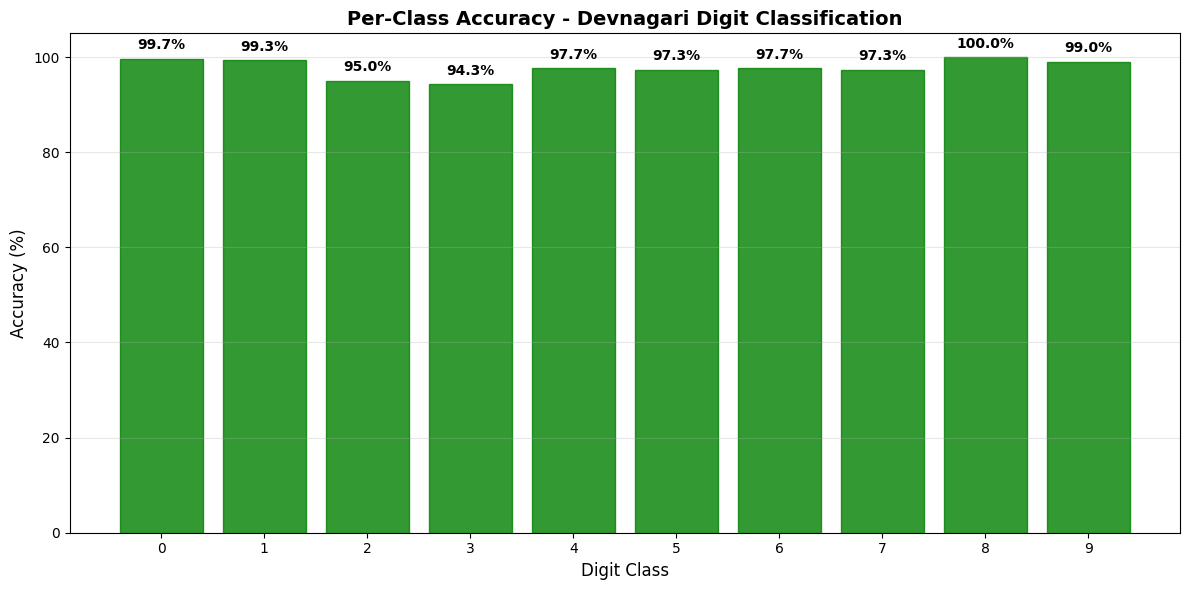


Per-Class Accuracy:
  Digit 0: 99.67%
  Digit 1: 99.33%
  Digit 2: 95.00%
  Digit 3: 94.33%
  Digit 4: 97.67%
  Digit 5: 97.33%
  Digit 6: 97.67%
  Digit 7: 97.33%
  Digit 8: 100.00%
  Digit 9: 99.00%


In [30]:
# Calculate per-class accuracy
class_accuracy = []
for i in range(10):
    class_mask = (true_labels == i)
    class_correct = np.sum((predicted_labels == i) & class_mask)
    class_total = np.sum(class_mask)
    class_acc = (class_correct / class_total * 100) if class_total > 0 else 0
    class_accuracy.append(class_acc)

# Plot per-class accuracy
plt.figure(figsize=(12, 6))
bars = plt.bar(range(10), class_accuracy, color='steelblue', edgecolor='black', alpha=0.8)

# Color bars based on accuracy
for i, bar in enumerate(bars):
    if class_accuracy[i] >= 90:
        bar.set_color('green')
    elif class_accuracy[i] >= 75:
        bar.set_color('orange')
    else:
        bar.set_color('red')

plt.xlabel('Digit Class', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Per-Class Accuracy - Devnagari Digit Classification',
          fontsize=14, fontweight='bold')
plt.xticks(range(10))
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(class_accuracy):
    plt.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for i, acc in enumerate(class_accuracy):
    print(f"  Digit {i}: {acc:.2f}%")

## Display Misclassified Images

Total misclassified images: 68


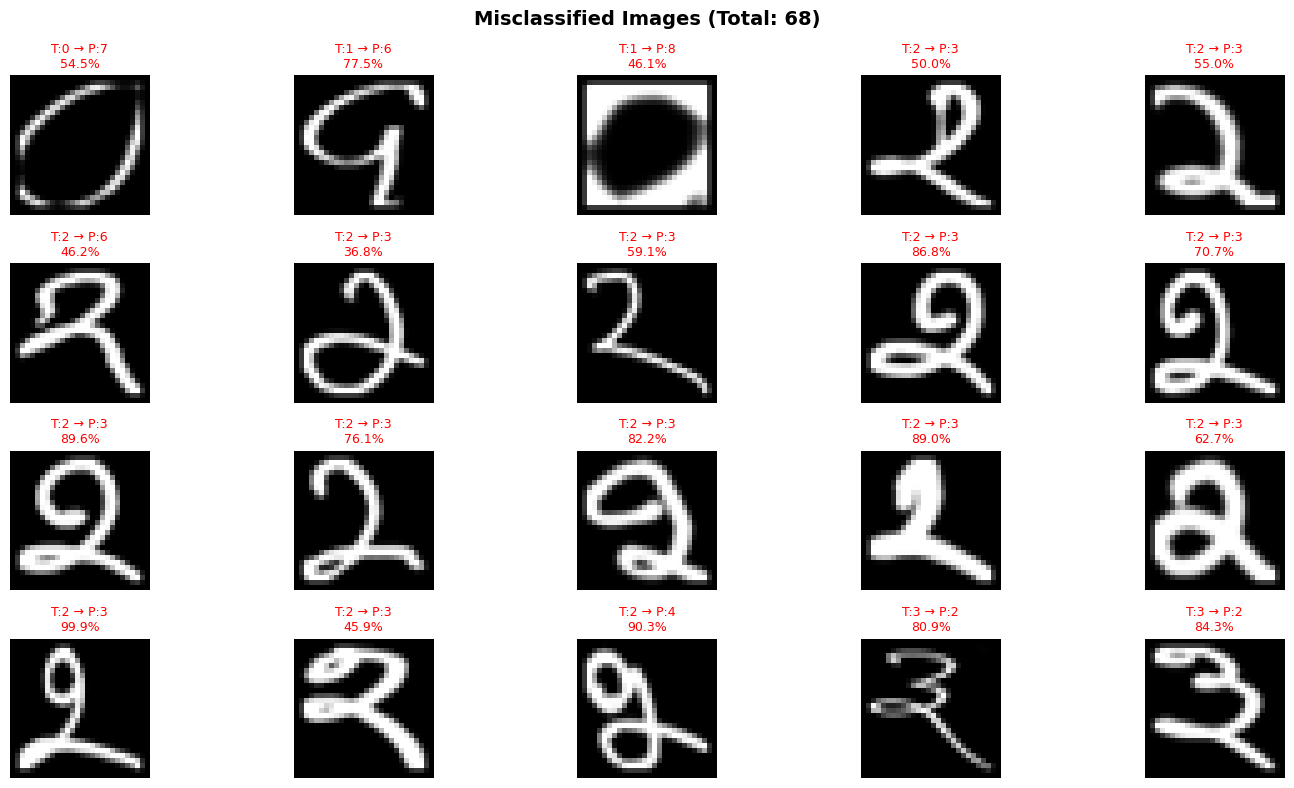

In [31]:
# Find misclassified images
misclassified_idx = np.where(predicted_labels != true_labels)[0]

print(f"Total misclassified images: {len(misclassified_idx)}")

if len(misclassified_idx) > 0:
    # Display up to 20 misclassified images
    num_to_show = min(20, len(misclassified_idx))

    plt.figure(figsize=(15, 8))
    for i in range(num_to_show):
        idx = misclassified_idx[i]
        plt.subplot(4, 5, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')

        predicted = predicted_labels[idx]
        true = true_labels[idx]
        confidence = predictions[idx][predicted] * 100

        plt.title(f"T:{true} → P:{predicted}\n{confidence:.1f}%",
                  fontsize=9, color='red')
        plt.axis("off")

    plt.suptitle(f"Misclassified Images (Total: {len(misclassified_idx)})",
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("All images were correctly classified!")

## Final Summary

In [32]:
# Print final summary
print("\n" + "-"*60)
print("FINAL MODEL SUMMARY")
print("/"*60)
print(f"\nModel Architecture:")
print(f"  Input Layer: {img_height * img_width} neurons (28x28 flattened)")
print(f"  Hidden Layer 1: 64 neurons (sigmoid)")
print(f"  Hidden Layer 2: 128 neurons (sigmoid)")
print(f"  Hidden Layer 3: 256 neurons (sigmoid)")
print(f"  Output Layer: {num_classes} neurons (softmax)")

print(f"\nTraining Configuration:")
print(f"  Optimizer: Adam")
print(f"  Loss Function: Categorical Crossentropy")
print(f"  Batch Size: {batch_size}")
print(f"  Epochs Trained: {len(history.history['loss'])}")
print(f"  Validation Split: 20%")

print(f"\nDataset:")
print(f"  Training Samples: {len(x_train)}")
print(f"  Testing Samples: {len(x_test)}")

print(f"\nPerformance:")
print(f"  Final Training Loss: {train_loss[-1]:.4f}")
print(f"  Final Training Accuracy: {train_acc[-1]:.4f} ({train_acc[-1]*100:.2f}%)")
print(f"  Final Validation Loss: {val_loss[-1]:.4f}")
print(f"  Final Validation Accuracy: {val_acc[-1]:.4f} ({val_acc[-1]*100:.2f}%)")
print(f"  Test Loss: {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

print(f"\nModel Saved: {model_filename}")
print("="*60)


------------------------------------------------------------
FINAL MODEL SUMMARY
////////////////////////////////////////////////////////////

Model Architecture:
  Input Layer: 784 neurons (28x28 flattened)
  Hidden Layer 1: 64 neurons (sigmoid)
  Hidden Layer 2: 128 neurons (sigmoid)
  Hidden Layer 3: 256 neurons (sigmoid)
  Output Layer: 10 neurons (softmax)

Training Configuration:
  Optimizer: Adam
  Loss Function: Categorical Crossentropy
  Batch Size: 128
  Epochs Trained: 27
  Validation Split: 20%

Dataset:
  Training Samples: 17000
  Testing Samples: 3000

Performance:
  Final Training Loss: 0.0502
  Final Training Accuracy: 0.9843 (98.43%)
  Final Validation Loss: 0.0757
  Final Validation Accuracy: 0.9791 (97.91%)
  Test Loss: 0.0768
  Test Accuracy: 0.9773 (97.73%)

Model Saved: devnagari_fcn_model.h5
